# Análise Exploratória e Criação de Produtos de Dados
## Projeto Aplicado I

### 1. Extract dos Dados e Importação de Bibliotecas Necessárias

In [10]:
# Importação das bibliotecas necessárias
import pandas as pd
import kagglehub as kh
import matplotlib.pyplot as plt
import seaborn as sbn
import os  

# Realizando a extração dos dados via biblioteca da Kagglehub
path = kh.dataset_download("srisyra02/zomato-market-analysis")

# Encontrando o arquivo CSV dentro da pasta baixada e carregando no Pandas
caminho_arquivo = os.path.join(path, "Zomato Restaurant Dataset.csv")
df = pd.read_csv(caminho_arquivo)

# Exibe as 5 primeiras linhas para confirmar que deu certo
df.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


### 2. Cálculo de NAs e Estatísticas Básicas

In [15]:
# Quantidade de NAs (Valores Nulos) em cada coluna
print("--- Quantidade de NAs ---")
print(df.isnull().sum())

--- Quantidade de NAs ---
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [14]:
# Resumo estatístico: Número de exemplares (count), Média (mean), 

# Desvio Padrão (std), Mínimo (min) e Máximo (max)
print("\n--- Resumo Estatístico ---")
resumo = df[['Aggregate rating', 'Average Cost for two']].describe()
print(resumo)


--- Resumo Estatístico ---
       Aggregate rating  Average Cost for two
count       9551.000000           9551.000000
mean           2.666370           1199.210763
std            1.516378          16121.183073
min            0.000000              0.000000
25%            2.500000            250.000000
50%            3.200000            400.000000
75%            3.700000            700.000000
max            4.900000         800000.000000


### 3. Cálculo de Variância

In [8]:
# Cálculo da Variância
print("--- Variância ---")
print("Variância das Notas: ", df['Aggregate rating'].var())
print("Variância do Custo: ", df['Average Cost for two'].var())

--- Variância ---
Variância das Notas:  2.299400842761455
Variância do Custo:  259892543.6892915


### 4. Gráficos de Distribuição e Outliers

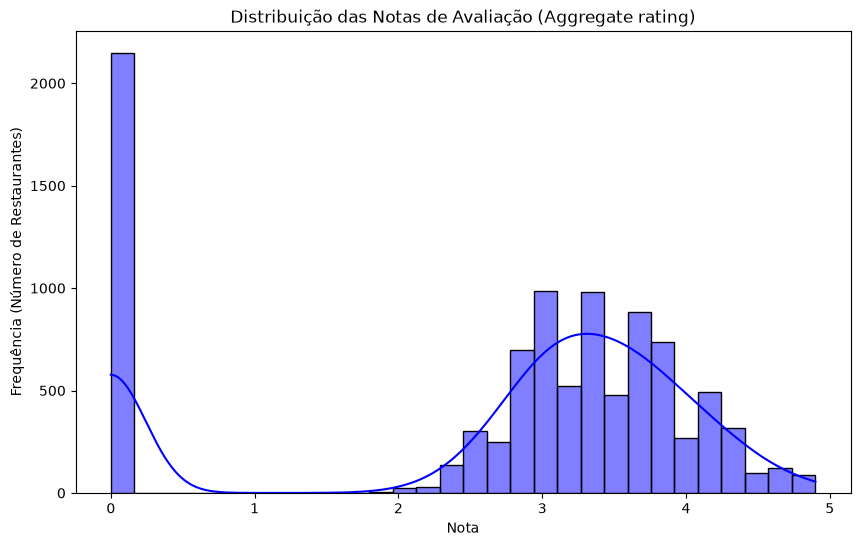

In [11]:
plt.figure(figsize=(10, 6))
# Utilizando o seaborn (importado como sbn) para criar o histograma
sbn.histplot(df['Aggregate rating'], bins=30, kde=True, color='blue')
plt.title('Distribuição das Notas de Avaliação (Aggregate rating)')
plt.xlabel('Nota')
plt.ylabel('Frequência (Número de Restaurantes)')
plt.show()

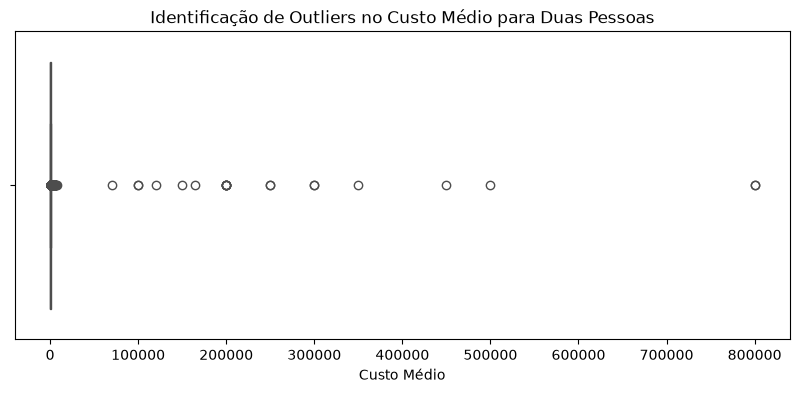

In [12]:
plt.figure(figsize=(10, 4))
# O Boxplot é o gráfico padrão da estatística para provar visualmente os outliers
sbn.boxplot(x=df['Average Cost for two'], color='orange')
plt.title('Identificação de Outliers no Custo Médio para Duas Pessoas')
plt.xlabel('Custo Médio')
plt.show()